In [ ]:
!pip install pyreadstat
# !pip install scikeras tensorflow scikit-learn

^C


In [ ]:
# pip install --upgrade tensorflow

In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


2025-06-17 14:06:56.131043: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750169216.356898      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750169216.423379      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.18.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import pyreadstat
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from collections import Counter
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
import os
import random
import numpy as np
import tensorflow as tf

def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)         # Python hash seed
    random.seed(seed)                                # Python random module
    np.random.seed(seed)                             # NumPy
    tf.random.set_seed(seed)                         # TensorFlow
    tf.keras.utils.set_random_seed(seed)             # For keras randomness
    tf.config.experimental.enable_op_determinism()   # Make ops deterministic

# Call this before training
set_seed(42)


# EDA

In [5]:
df_ch = pyreadstat.read_sav('/kaggle/input/malnutrition/ch.sav')[0]
# data = pd.read_spss('/kaggle/input/malnutrition/ch.sav')

# Renaming the columns
df1 = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = df1.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df2 = df1.copy()
df2.dropna(inplace=True)

df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({1: 1, 2: 0})
df2.head(10)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,7.8,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
2,2.0,11.1,1.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
3,1.0,9.3,1.0,1.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,0
5,0.0,6.9,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
6,1.0,10.5,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,0
7,1.0,10.4,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
10,1.0,8.8,1.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0,1.0,1
13,1.0,9.7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
15,1.0,10.3,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
16,1.0,7.7,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,1


In [7]:
#Scaling child weight
scaler = StandardScaler()
df2['child_weight'] = scaler.fit_transform(df2[['child_weight']])

df2.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,-0.617934,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
2,2.0,0.797956,1.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0


In [ ]:
# # Label/one-hot-encoding for Ordinal/nominal features
# le = LabelEncoder()
# df2['mother_education'] = le.fit_transform(df2['mother_education'])
# df2['wealth_index'] = le.fit_transform(df2['wealth_index'])
# df2 = pd.get_dummies(df2, columns = ['province'])
# df = df2.astype(int)
# df.head(10)

# Artificial Neural Network

In [8]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Recall
from keras_tuner import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential

In [9]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [10]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['recall'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,  
    epochs=100,            
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

I0000 00:00:1750169270.480453      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750169270.481115      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100


2025-06-17 14:07:51.942850: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


144/144 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.7877 - recall: 0.4086 - val_loss: 0.6598 - val_recall: 0.4483
Epoch 2/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6760 - recall: 0.4293 - val_loss: 0.6435 - val_recall: 0.5517
Epoch 3/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6550 - recall: 0.4970 - val_loss: 0.6249 - val_recall: 0.6054
Epoch 4/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6402 - recall: 0.5222 - val_loss: 0.6180 - val_recall: 0.6322
Epoch 5/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6304 - recall: 0.5615 - val_loss: 0.6091 - val_recall: 0.6207
Epoch 6/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6199 - recall: 0.5658 - val_loss: 0.6036 - val_recall: 0.6207
Epoch 7/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6059 - recall: 0.5901 - val_loss: 0.5974 - val_recall: 0.6590
Epoch 8/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5967 - recall: 0.5977 - val_loss: 0.5915 - val_recall: 0.6858
Epoch 9/100


In [ ]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
# from tensorflow.keras.optimizers import Adam
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import RandomizedSearchCV
# from scikeras.wrappers import KerasClassifier

# # 🧠 Model builder function
# def create_model(units=32, num_hidden_layers=1, dropout_rate=0.2,
#                  learning_rate=0.001, use_batchnorm=False):
#     model = Sequential()
#     model.add(Input(shape=(X_train.shape[1],)))
#     model.add(Dense(units, activation='relu'))
#     if use_batchnorm:
#         model.add(BatchNormalization())
#     model.add(Dropout(dropout_rate))
    
#     for _ in range(num_hidden_layers - 1):
#         model.add(Dense(units, activation='relu'))
#         if use_batchnorm:
#             model.add(BatchNormalization())
#         model.add(Dropout(dropout_rate))
    
#     model.add(Dense(1, activation='sigmoid'))
    
#     model.compile(
#         optimizer=Adam(learning_rate=learning_rate),
#         loss='binary_crossentropy',
#         metrics=['Recall']
#     )
#     return model

# # 🔧 Wrap in Scikeras KerasClassifier
# model = KerasClassifier(model=create_model, verbose=0)

# # 🧪 Define hyperparameter space
# param_dist = {
#     'model__units': [32, 64, 128],
#     'model__num_hidden_layers': [1, 2, 3],
#     'model__dropout_rate': [0.2, 0.3, 0.4],
#     'model__learning_rate': [1e-2, 1e-3, 1e-4],
#     'model__use_batchnorm': [True, False],
#     'batch_size': [32, 64],
#     'epochs': [30, 50]
# }

# # 🎯 Randomized search with 5-fold CV optimizing for recall
# search = RandomizedSearchCV(
#     estimator=model,
#     param_distributions=param_dist,
#     n_iter=20,
#     scoring='recall',
#     cv=5,
#     verbose=1,
#     n_jobs=1
# )

# # 🚀 Run the search
# search.fit(X_train, y_train)

# # 🥇 Best model and parameters
# print("Best Recall:", search.best_score_)
# print("Best Params:", search.best_params_)

# # You can now use the best model:
# best_model = search.best_estimator_

In [14]:
# Define the model using the best hyperparameters
def create_best_model(input_dim):
    model_new = Sequential()
    model_new.add(Input(shape=(input_dim,)))

    # First hidden layer
    model_new.add(Dense(128, activation='relu'))
    model_new.add(BatchNormalization())  # use_batchnorm = True
    model_new.add(Dropout(0.4))

    # Second hidden layer
    model_new.add(Dense(128, activation='relu'))
    model_new.add(BatchNormalization())
    model_new.add(Dropout(0.4))

    # Third hidden layer
    model_new.add(Dense(128, activation='relu'))
    model_new.add(BatchNormalization())
    model_new.add(Dropout(0.4))

    # Output layer
    model_new.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model_new.compile(
        optimizer=Adam(learning_rate=0.01),
        loss=BinaryCrossentropy(),
        metrics=[Recall()]
    )

    return model_new

# Example usage
model_new = create_best_model(input_dim=X_train.shape[1])

# Train the model
history = model_new.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]  # if you’ve defined EarlyStopping already
)

Epoch 1/50


2025-06-17 14:11:22.543560: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.8413 - recall_1: 0.4768 - val_loss: 0.6403 - val_recall_1: 0.5441
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6665 - recall_1: 0.5002 - val_loss: 0.6051 - val_recall_1: 0.5785
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6122 - recall_1: 0.5573 - val_loss: 0.6015 - val_recall_1: 0.6169
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6039 - recall_1: 0.5907 - val_loss: 0.5962 - val_recall_1: 0.7050
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5957 - recall_1: 0.5589 - val_loss: 0.5691 - val_recall_1: 0.5249
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5845 - recall_1: 0.5542 - val_loss: 0.5786 - val_recall_1: 0.5862
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5840 - recall_1: 0.5583 - val_loss: 0.5546 - val_recall_1: 0.6820
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5845 - recall_1: 0.5756 - val_loss: 0.5765 - val_recall_1: 0.5594
Ep

In [16]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(
        units=hp.Int('units_input', min_value=16, max_value=128, step=16),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.5, step=0.1)))
    model.add(Dense(
        units=hp.Int('units_hidden', min_value=8, max_value=64, step=8),
        activation='relu'
    ))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('lr', [1e-1, 1e-2, 1e-3, 1e-4])),
        loss=BinaryCrossentropy(),
        metrics=[Recall()]
    )
    return model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


tuner = RandomSearch(
    build_model,
    objective='val_recall',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='binary_class_tuning'
)

tuner.search(X_train, y_train, epochs=50, validation_split=0.2, callbacks=[early_stop])
best_model = tuner.get_best_models(num_models=1)[0]


Trial 10 Complete [00h 00m 11s]
val_recall: 0.6896551847457886

Best val_recall So Far: 0.7509578466415405
Total elapsed time: 00h 02m 19s


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


NameError: name 'best_hps' is not defined

In [17]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

best_model = build_model(best_hps)
best_model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early_stop])

Epoch 1/100


2025-06-17 14:19:16.211545: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.7055 - recall_1: 0.3713 - val_loss: 0.6519 - val_recall_1: 0.5709
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6586 - recall_1: 0.4394 - val_loss: 0.6388 - val_recall_1: 0.6130
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6505 - recall_1: 0.4254 - val_loss: 0.6155 - val_recall_1: 0.6475
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6231 - recall_1: 0.5221 - val_loss: 0.6275 - val_recall_1: 0.7356
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6286 - recall_1: 0.5488 - val_loss: 0.6175 - val_recall_1: 0.6590
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6187 - recall_1: 0.5651 - val_loss: 0.5865 - val_recall_1: 0.6284
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6045 - recall_1: 0.5660 - val_loss: 0.5889 - val_recall_1: 0.5785
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6054 - recall_1: 0.5281 - val_loss: 0.5804 - val_recall_1: 0.

In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(f"Input layer units: {best_hps.get('units_input')}")
print(f"Hidden layer units: {best_hps.get('units_hidden')}")
print(f"Dropout rate: {best_hps.get('dropout')}")
print(f"Learning rate: {best_hps.get('lr')}")


In [11]:
y_probs_model = model.predict(X_test)
y_probs_model = (y_probs_model > 0.5).astype("int")

print(classification_report(y_test, y_probs_model))

2025-06-17 14:09:10.106934: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.72      0.75      0.74       397
           1       0.67      0.63      0.65       320

    accuracy                           0.70       717
   macro avg       0.70      0.69      0.69       717
weighted avg       0.70      0.70      0.70       717



In [15]:
y_probs_model_new = model_new.predict(X_test)
y_pred_model_new = (y_probs_model_new > 0.5).astype("int")

print(classification_report(y_test, y_pred_model_new))

 1/23 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step

2025-06-17 14:11:54.077815: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.74      0.74      0.74       397
           1       0.68      0.68      0.68       320

    accuracy                           0.72       717
   macro avg       0.71      0.71      0.71       717
weighted avg       0.72      0.72      0.72       717



In [18]:
y_probsbest_model = best_model.predict(X_test).ravel()
y_predbest_model = (y_probsbest_model > 0.5).astype(int)

print(classification_report(y_test, y_predbest_model))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.71      0.85      0.77       397
           1       0.75      0.57      0.64       320

    accuracy                           0.72       717
   macro avg       0.73      0.71      0.71       717
weighted avg       0.73      0.72      0.71       717



2025-06-17 14:19:51.740356: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
# Use model.predict() and flatten to 1D
y_probas = model.predict(X_test).ravel()

# Compute Average Precision Score
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Average Precision: 0.7647904372604957


2025-06-17 14:09:26.353803: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


2025-06-17 14:09:35.414569: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


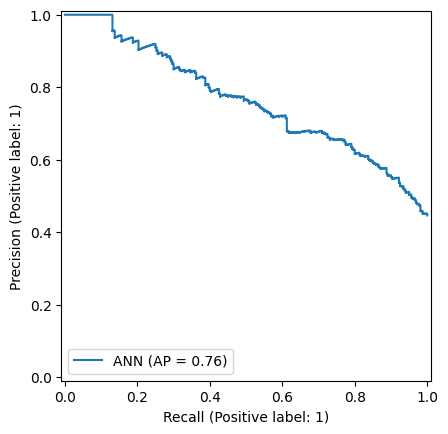

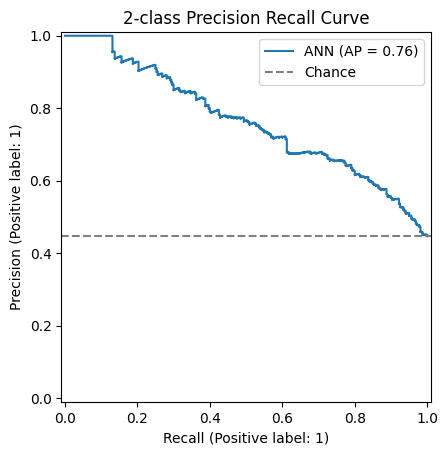

In [13]:
# Get predicted probabilities
y_probas = model.predict(X_test).ravel()

# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probas,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()
